# **Perguntas a responder:**

1. Os 5 órgãos com maior custo total?
2. Os 3 destinos com maior custo médio por viagem?
3. A viagem de maior duração e seu custo total?
4. Qual o tipo de pagamento com maior valor médio?
5. Qual o meio de transporte mais usado nos trechos?
6. Qual UF de destino aparece em mais trechos?
7. Qual órgão pagou mais no total?

### **Importações e Criação de funções**


In [54]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from database import banco
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import squarify

warnings.filterwarnings("ignore")

PASTA_RAIZ = Path.cwd().parent
PASTA_SQL_GOLD = PASTA_RAIZ / "sql" / "gold"

lista_perguntas = [
    ("pergunta_1", "top5_orgaos_custo_total"),
    ("pergunta_2", "top3_destinos_custo_medio"),
    ("pergunta_3", "viagem_maior_duracao"),
    ("pergunta_4", "tipo_pagamento_valor_medio"),
    ("pergunta_5", "meio_transporte_utilizacao"),
    ("pergunta_6", "destino_uf_frequencia"),
    ("pergunta_7", "orgaos_pagadores_custo_total"),
]
# Ajustando a visuaçização do Pandas, devido aos valores serem altos e acabarem dificultando a visualização
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
def carregar_sql(caminho):
    with open(caminho, "r", encoding="utf-8") as arquivo:
        return arquivo.read()

In [4]:
def criar_gold_view(conexao, nome_tabela, sql):

    print(f"Criando a GOLD da tabela gold_{nome_tabela}")
    banco.executar(conexao, f"DROP TABLE IF EXISTS gold_{nome_tabela}")
    banco.executar(conexao, f"CREATE TABLE gold_{nome_tabela} AS {sql}")

    print(f"Criando a VIEW da tabela {nome_tabela}")
    banco.executar(conexao, f"DROP VIEW IF EXISTS vw_{nome_tabela}")
    banco.executar(conexao, f"CREATE VIEW vw_{nome_tabela} AS {sql}")

In [5]:
def analisar(pergunta):
    conexao = None

    try:
        conexao = banco.conectar()
        caminho_sql = PASTA_SQL_GOLD / f"{lista_perguntas[pergunta-1][0]}.sql"
        sql = carregar_sql(caminho_sql)
        df = pd.read_sql(sql, conexao)

    except Exception as erro:
        print("[ERRO] Algo deu errado:", erro)
        raise

    finally:
        if conexao:
            conexao.close()

    return df

# **Início das análises**

### Pergunta_1: Os 5 órgãos com maior custo total?

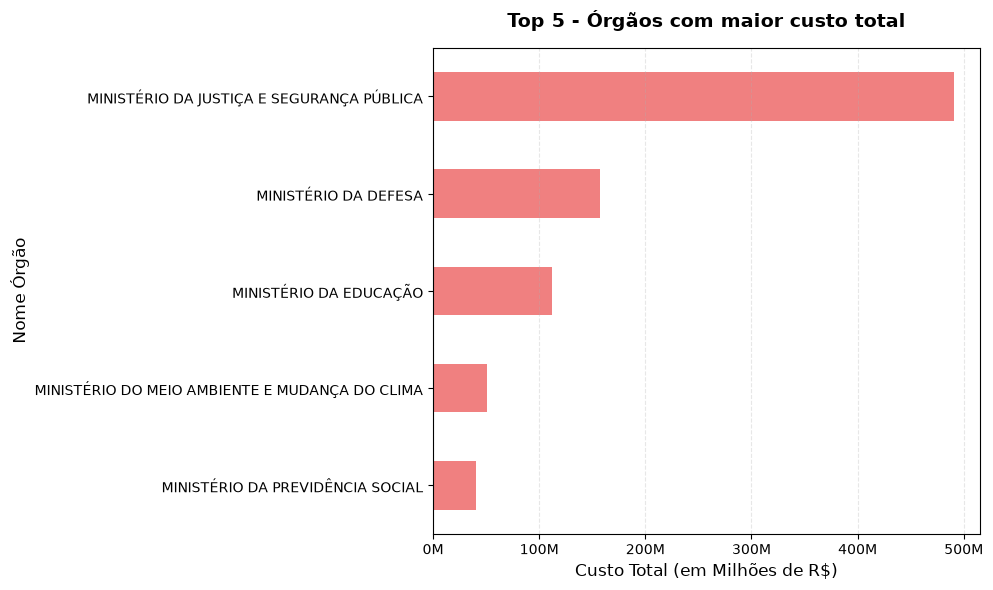

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,nome_orgao_superior,custo_total
0,MINISTÉRIO DA JUSTIÇA E SEGURANÇA PÚBLICA,"490,813,474.85"
1,MINISTÉRIO DA DEFESA,"157,059,698.59"
2,MINISTÉRIO DA EDUCAÇÃO,"112,519,456.96"
3,MINISTÉRIO DO MEIO AMBIENTE E MUDANÇA DO CLIMA,"50,548,377.44"
4,MINISTÉRIO DA PREVIDÊNCIA SOCIAL,"40,921,476.10"


In [ ]:
df = analisar(1)

df["custo_total"] = df["custo_total"].astype(str).str.replace(",", "")
df["custo_total"] = pd.to_numeric(df["custo_total"])
df = df.sort_values(by="custo_total", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
df.plot.barh(
    x="nome_orgao_superior", y="custo_total", ax=ax, color="lightcoral", legend=False
)

def milhões_formatter(x, pos):
    return f"{x*1e-6:.0f}M"

ax.xaxis.set_major_formatter(ticker.FuncFormatter(milhões_formatter))
ax.set_title(
    "Top 5 - Órgãos com maior custo total", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Custo Total (em Milhões de R$)", fontsize=12)
ax.set_ylabel("Nome Órgão", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_total", ascending=False)

### Pergunta_2: Os 3 destinos com maior custo médio por viagem?

Criando a GOLD da tabela gold_top3_destinos_custo_medio
Criando a VIEW da tabela top3_destinos_custo_medio


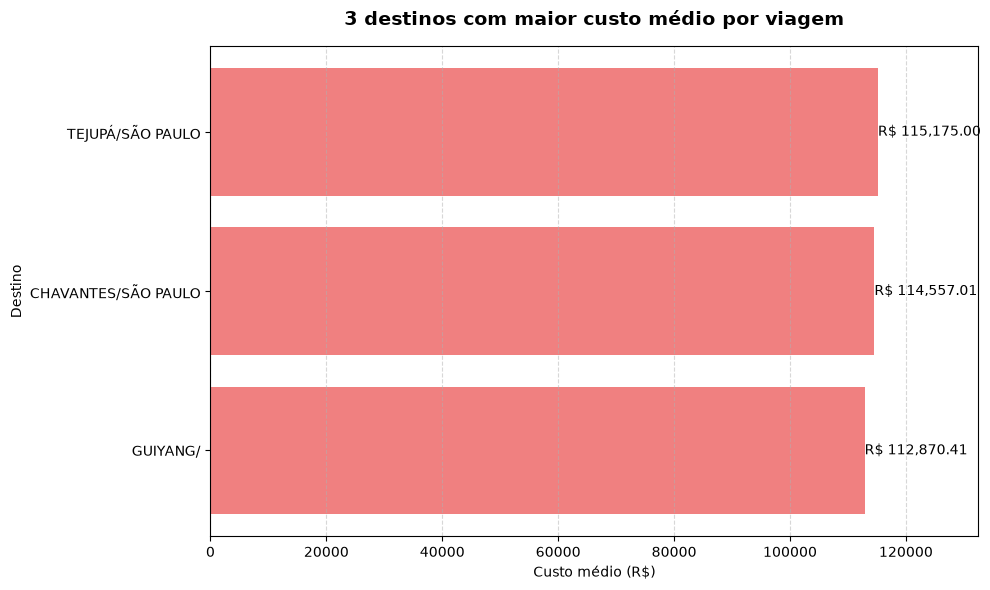

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,destino,custo_medio
0,TEJUPÁ/SÃO PAULO,"115,175.00"
1,CHAVANTES/SÃO PAULO,"114,557.01"
2,GUIYANG/,"112,870.41"


In [ ]:
try:
    conexao = banco.conectar()
    caminho_sql = PASTA_SQL_GOLD / f"{lista_perguntas[1][0]}.sql"
    sql = carregar_sql(caminho_sql)
    criar_gold_view(conexao, lista_perguntas[1][1], sql)

except Exception as erro:
    print("[ERRO] Algo deu errado:", erro)
    raise

finally:
    if conexao:
        conexao.close()
df = analisar(2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df["destino"], df["custo_medio"], color="lightcoral")
ax.invert_yaxis()
ax.set_title("3 destinos com maior custo médio por viagem", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Custo médio (R$)")
ax.set_ylabel("Destino")
for i, valor in enumerate(df["custo_medio"]):
    ax.text(valor, i, f"R$ {valor:,.2f}", va="center", ha="left")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_xlim(0, df["custo_medio"].max() * 1.15)
plt.tight_layout()
plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_medio", ascending=False)


### Pergunta_3: A viagem de maior duração e seu custo total?


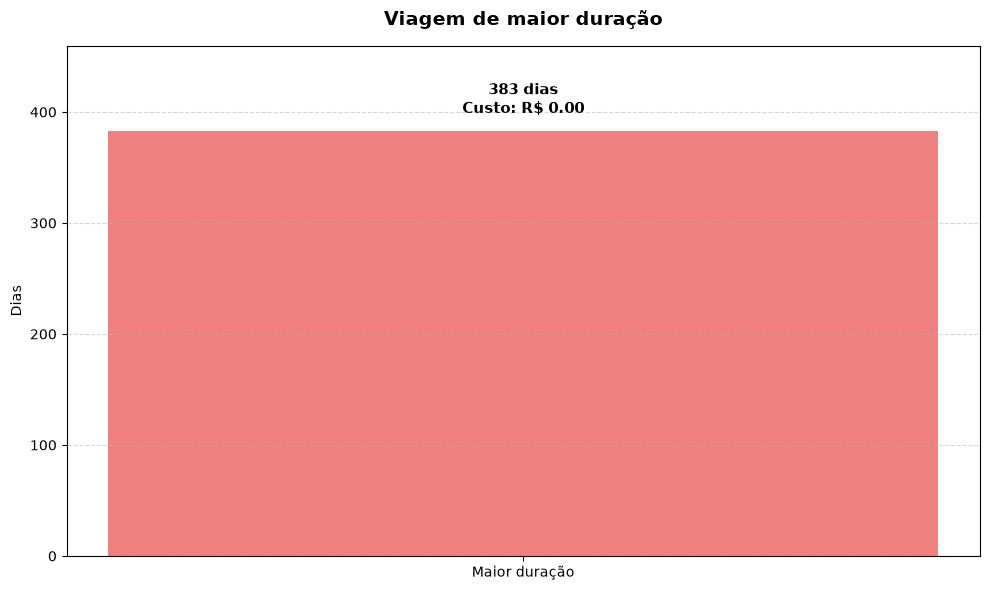

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,id_viagem,nome_viajante,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,2025-01-13,2026-01-31,383,0.00


In [45]:
df = analisar(3)

plt.figure(figsize=(10, 6))

plt.bar(["Maior duração"], df["duracao_dias"], color="lightcoral", width=0.5)

plt.title("Viagem de maior duração", fontsize=14, weight="bold", pad=15)
plt.ylabel("Dias")
plt.ylim(0, df["duracao_dias"].max() * 1.2)
plt.text(
    0,
    df["duracao_dias"].max() * 1.03,
    f"{df['duracao_dias'].max()} dias\nCusto: R$ {df['valor_total'].max():,.2f}",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="duracao_dias", ascending=False)

### Pergunta_4: Qual o tipo de pagamento com maior valor médio?


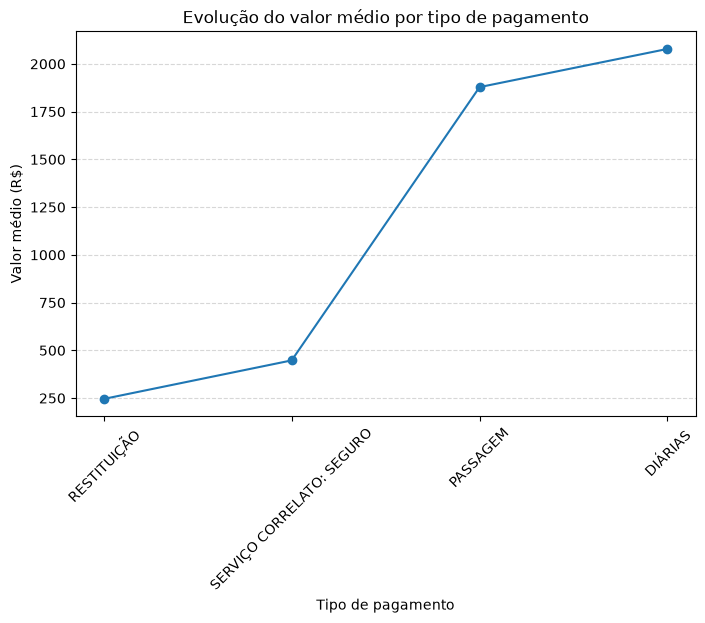

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,tipo_pagamento,valor_medio
0,DIÁRIAS,"2,078.28"
1,PASSAGEM,"1,878.34"
2,SERVIÇO CORRELATO: SEGURO,447.51
3,RESTITUIÇÃO,245.70


In [ ]:
df = analisar(4)

df = df.sort_values(
    "valor_medio"
)

plt.figure(figsize=(10, 6))

plt.plot(
    df["tipo_pagamento"],
    df["valor_medio"],
    marker="o"
)

plt.title("Evolução do valor médio por tipo de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="valor_medio", ascending=False)

### Pergunta_5: Qual o meio de transporte mais usado nos trechos?


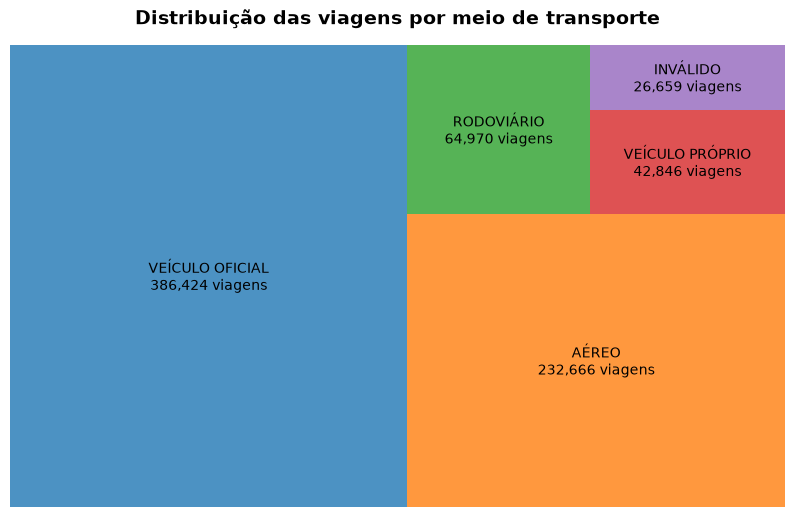

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,meio_transporte,qtde_viagens
0,VEÍCULO OFICIAL,386424
1,AÉREO,232666
2,RODOVIÁRIO,64970
3,VEÍCULO PRÓPRIO,42846
4,INVÁLIDO,26659


In [62]:
df = analisar(5)

df = df.sort_values(
    "qtde_viagens",
    ascending=False
)
cores = plt.colormaps["tab10"](
    range(len(df))
)
plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=df["qtde_viagens"],
    label=[
        f"{meio}\n{qtde:,.0f} viagens"
        for meio, qtde in zip(
            df["meio_transporte"],
            df["qtde_viagens"]
        )
    ],
    color=cores,
    alpha=0.8
)

plt.title("Distribuição das viagens por meio de transporte", fontsize=14, weight="bold", pad=15)
plt.axis("off")
plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="qtde_viagens", ascending=False)

### Pergunta_6: Qual UF de destino aparece em mais trechos?


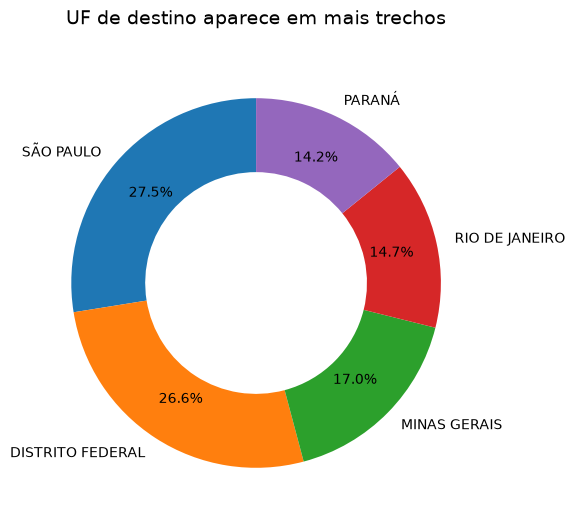

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,destino_uf,quantidade
0,SÃO PAULO,82722
1,DISTRITO FEDERAL,79962
2,MINAS GERAIS,50965
3,RIO DE JANEIRO,44197
4,PARANÁ,42603


In [66]:
df = analisar(6)
plt.figure(figsize=(10, 6))
plt.pie(
    df["quantidade"],
    labels=df["destino_uf"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4},
    pctdistance=0.75,     # posição dos percentuais dentro da rosca
    labeldistance=1.1     # distância das legendas
)
plt.title(
    "UF de destino aparece em mais trechos",
    fontsize=14,
    pad=20
)

plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="quantidade", ascending=False)

### Pergunta_7: Qual órgão pagou mais no total?

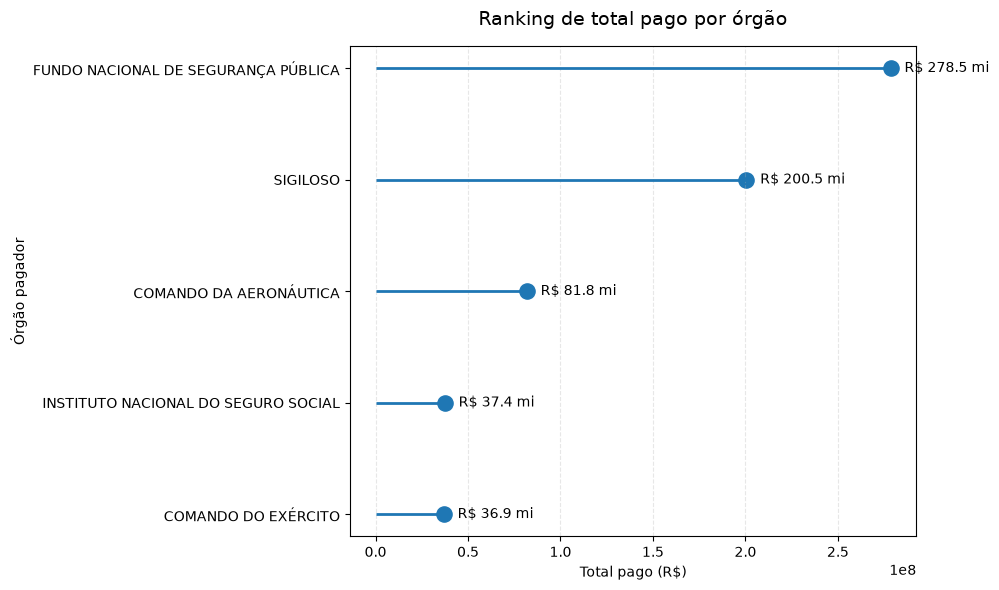

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,nome_orgao_pagador,total_pago
0,FUNDO NACIONAL DE SEGURANÇA PÚBLICA,"278,481,047.89"
1,SIGILOSO,"200,484,801.68"
2,COMANDO DA AERONÁUTICA,"81,769,144.77"
3,INSTITUTO NACIONAL DO SEGURO SOCIAL,"37,427,601.45"
4,COMANDO DO EXÉRCITO,"36,872,643.95"


In [71]:
df = analisar(7)

df = df.sort_values(
    "total_pago",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.hlines(
    y=df["nome_orgao_pagador"],
    xmin=0,
    xmax=df["total_pago"],
    linewidth=2
)

plt.scatter(
    df["total_pago"],
    df["nome_orgao_pagador"],
    s=120
)

# Valores deslocados para direita
for valor, orgao in zip(
    df["total_pago"],
    df["nome_orgao_pagador"]
):
    plt.annotate(
        f"R$ {valor/1_000_000:.1f} mi",
        xy=(valor, orgao),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

plt.title(
    "Ranking de total pago por órgão",
    fontsize=14,
    pad=15
)

plt.xlabel("Total pago (R$)")
plt.ylabel("Órgão pagador")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)
plt.tight_layout()
plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="total_pago", ascending=False)